# Project Details:
# 1. Problem Statement:
Build a model to predict sales figures given other attributes of counterfeit medicine selling operations.
# 2. Data Files:
* counterfeit_train.csv: Contains training data with features and the target variable (sales figures).
* counterfeit_test.csv: Test data without the target variable. You need to predict and submit these sales figures in CSV format.
# 3.Evaluation Metric:
* The score is calculated as:
$$
\text{Score} = 1 - \left(\frac{\text{MAE}}{1660}\right)
$$,
where $MAE$ is the Mean Absolute Error.
* A score above 0.5 is required for project approval. Minimizing MAE is the focus.
# 4. Output Submission Requirements:
* Submit predictions in the exact format as sample_submission.csv.
* Column names, value types, and row counts must match the test data precisely.

# Importing Required Libraries

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Loading the Datasets

In [14]:
# Load the datasets
train_data = pd.read_csv('data/counterfeit_train.csv')
test_data = pd.read_csv('data/counterfeit_test.csv')

# Dataset Overview:
* Inspect column names, data types, and missing values.
* Analyze basic statistics of numerical features.

In [15]:
# EDA Step 1: Data Overview
print("\n--- Data Overview ---")
print(train_data.info())
print("\n--- Statistical Summary ---")
print(train_data.describe())


--- Data Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Medicine_ID          6818 non-null   object 
 1   Counterfeit_Weight   5652 non-null   float64
 2   DistArea_ID          6818 non-null   object 
 3   Active_Since         6818 non-null   int64  
 4   Medicine_MRP         6818 non-null   float64
 5   Medicine_Type        6818 non-null   object 
 6   SidEffect_Level      6818 non-null   object 
 7   Availability_rating  6818 non-null   float64
 8   Area_Type            6818 non-null   object 
 9   Area_City_Type       6818 non-null   object 
 10  Area_dist_level      6818 non-null   object 
 11  Counterfeit_Sales    6818 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 639.3+ KB
None

--- Statistical Summary ---
       Counterfeit_Weight  Active_Since  Medicine_MRP  Availability_rati

1. Training Data (counterfeit_train.csv):
* Contains features such as Medicine_ID, Counterfeit_Weight, DistArea_ID, Active_Since, Medicine_MRP, and more.
* Target variable: Counterfeit_Sales.
2. Test Data (counterfeit_test.csv):
* Similar structure to training data but excludes the Counterfeit_Sales column.
* The goal is to predict Counterfeit_Sales for the test dataset.

Key Observations:
* There are numerical and categorical features.
* Missing values exist (e.g., Counterfeit_Weight).
* Potential categorical features: Medicine_Type, SidEffect_Level, Area_Type, etc.
* Numerical features like Medicine_MRP, Availability_rating, and Counterfeit_Weight will likely be significant for modeling.

In [16]:
# EDA Step 2: Missing Values Analysis
missing_values = train_data.isnull().sum()
print("\n--- Missing Values ---")
print(missing_values[missing_values > 0])


--- Missing Values ---
Counterfeit_Weight    1166
dtype: int64


# Visualization
* Distribution of numerical features.
* Counts of categorical features.
* Correlation heatmap for numerical variables.

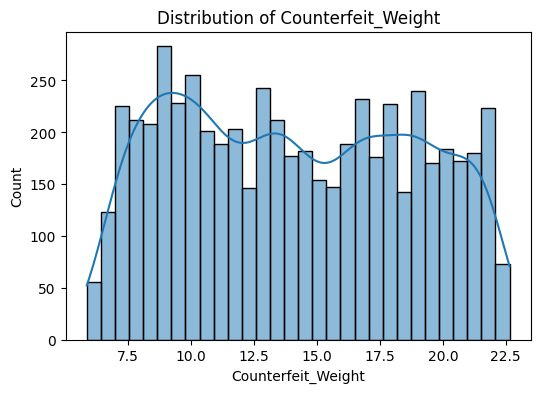

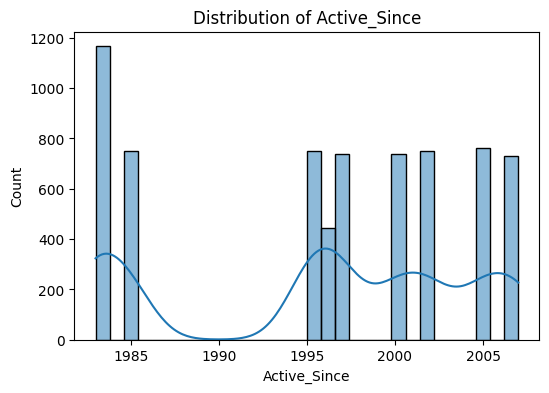

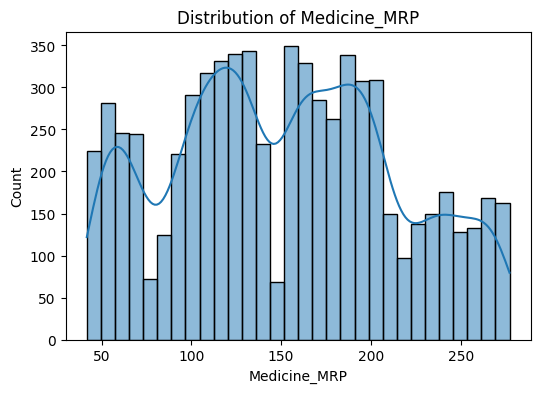

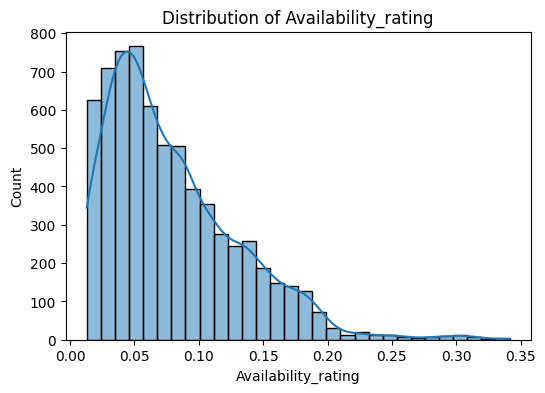

In [17]:
# EDA Step 3: Visualizations
# Distribution of numerical features
numerical_features = ['Counterfeit_Weight', 'Active_Since', 'Medicine_MRP', 'Availability_rating']
for col in numerical_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(train_data[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

**This plot visualizes the distribution of numerical features, allowing you to check for skewness or unusual patterns.**

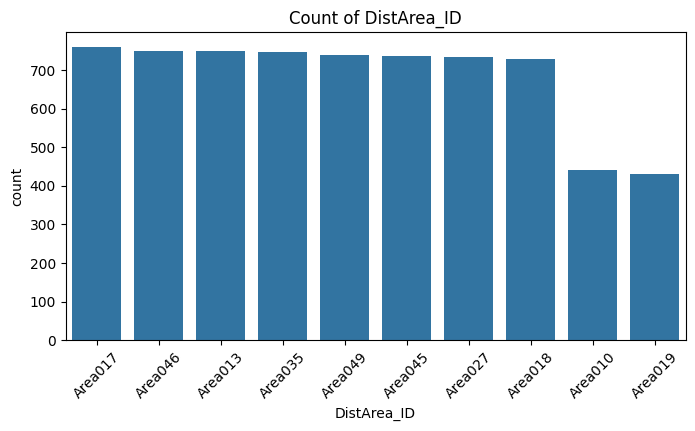

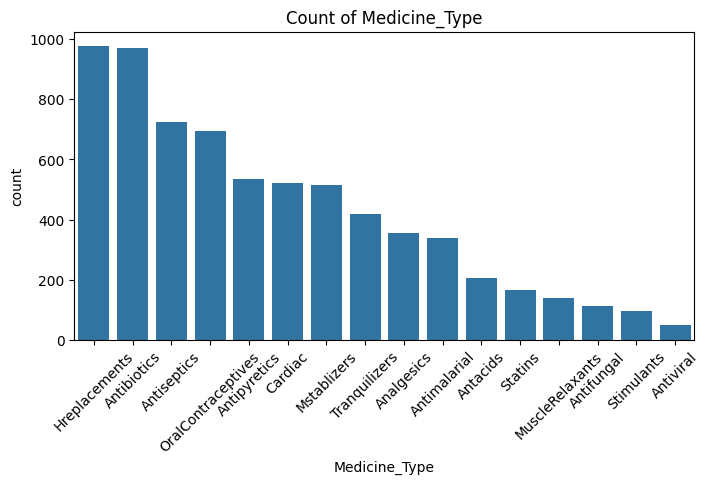

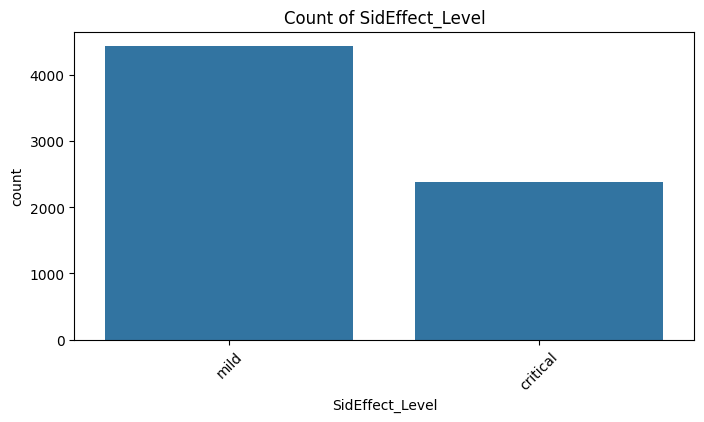

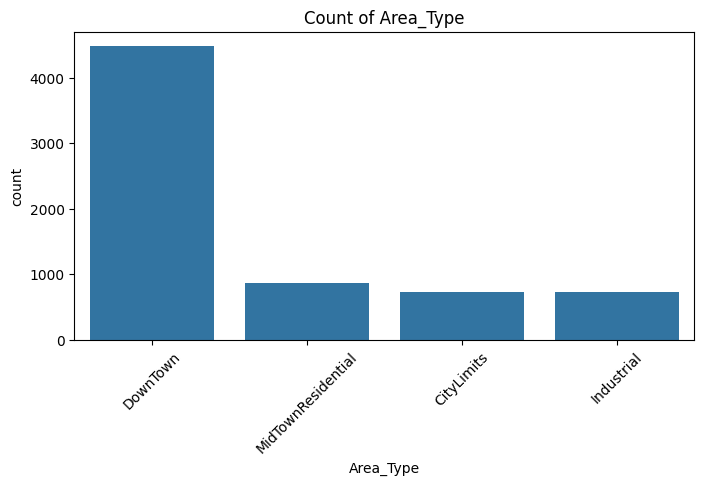

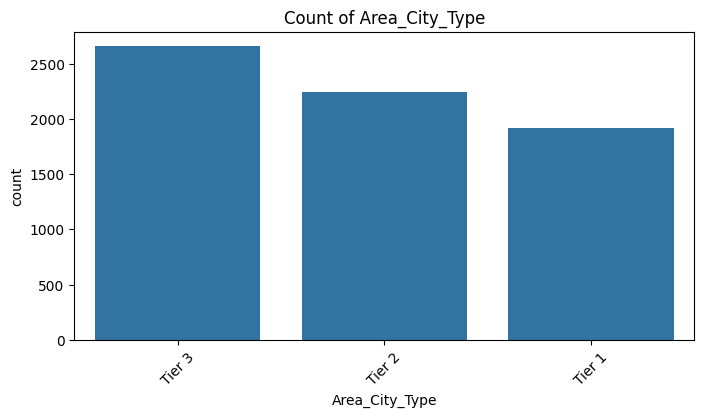

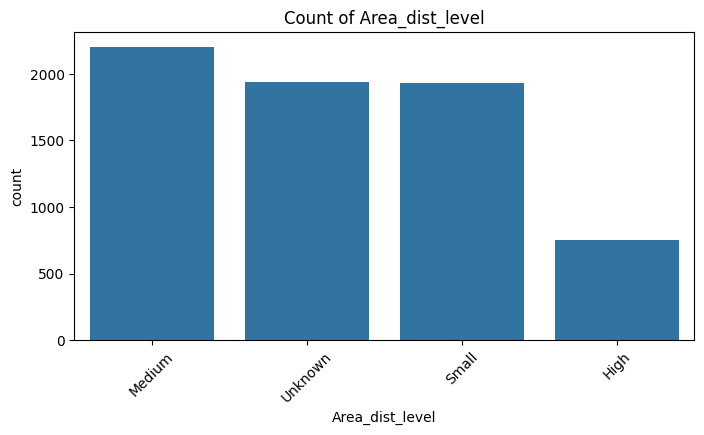

In [18]:
# Count plots for categorical features
categorical_features = ['DistArea_ID', 'Medicine_Type', 'SidEffect_Level', 'Area_Type', 'Area_City_Type', 'Area_dist_level']
for col in categorical_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, data=train_data, order=train_data[col].value_counts().index)
    plt.title(f"Count of {col}")
    plt.xticks(rotation=45)
    plt.show()

**This count plot provides insights into the frequency distribution of categorical features. Consider using it to detect imbalances in the categories.**

In [19]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation = train_data.corr()
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

ValueError: could not convert string to float: 'RRA15'

<Figure size 1000x800 with 0 Axes>

* We have an error in the code
**Steps To Resolve**
1. Check the Data Types of Columns: Use the following code to inspect which columns are non-numeric:

In [21]:
train_data.dtypes

Medicine_ID             object
Counterfeit_Weight     float64
DistArea_ID             object
Active_Since             int64
Medicine_MRP           float64
Medicine_Type           object
SidEffect_Level         object
Availability_rating    float64
Area_Type               object
Area_City_Type          object
Area_dist_level         object
Counterfeit_Sales      float64
dtype: object

2. Filter Only Numeric Columns: Create a new DataFrame with only numeric columns before calculating the correlation:

In [22]:
numeric_data = train_data.select_dtypes(include=['number'])
correlation = numeric_data.corr()

3. Handle Non-Numeric Columns: If you want to include non-numeric columns in some way:

* Encode Categorical Columns: Use techniques like one-hot encoding or Label Encoding to convert categorical data into numeric form.


In [23]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
for col in train_data.select_dtypes(include=['object']).columns:
    train_data[col] = label_encoder.fit_transform(train_data[col])

4. Inspect the Unique Values in Problematic Columns: If the column causing issues is categorical, inspect its values to decide how to handle them:

In [24]:
print(train_data['RRA15'].unique())

KeyError: 'RRA15'

**Still the problem is'nt resolved**


**I have tried to use the following code**


1. Check Available Columns in the DataFrame: Verify which columns are present in the DataFrame:

In [29]:
print(train_data.columns)

Index(['Medicine_ID', 'Counterfeit_Weight', 'DistArea_ID', 'Active_Since',
       'Medicine_MRP', 'Medicine_Type', 'SidEffect_Level',
       'Availability_rating', 'Area_Type', 'Area_City_Type', 'Area_dist_level',
       'Counterfeit_Sales'],
      dtype='object')


This will list all column names. Check if 'RRA15' is present or if there's a typo in the column name.

2. Ensure Correct Column Name: If the column exists but has leading/trailing spaces or incorrect casing, clean the column names:

In [30]:
train_data.columns = train_data.columns.str.strip()  # Remove leading/trailing spaces
train_data.columns = train_data.columns.str.lower()  # Convert to lowercase

Then, recheck for `RRA15`:

In [31]:
if 'rra15' in train_data.columns:
    print(train_data['rra15'].unique())

3. Handle Missing Column: If 'RRA15' genuinely does not exist, check for possible causes:
* Was the column dropped earlier? Review your code to see if this column was removed.
* Does the column exist in the original data? Ensure the dataset you're loading includes this column:

In [32]:
print(train_data.head())

   medicine_id  counterfeit_weight  distarea_id  active_since  medicine_mrp  \
0         1067              13.100            8          1995      160.2366   
1         1497                 NaN            5          1983      110.4384   
2          691               9.025            8          1995      259.4092   
3          405              11.800            8          1995       99.9830   
4          994                 NaN            4          1983       56.4402   

   medicine_type  sideffect_level  availability_rating  area_type  \
0              4                0             0.070422          1   
1             10                1             0.013000          0   
2              8                1             0.060783          1   
3             12                1             0.065555          1   
4              9                0             0.248859          3   

   area_city_type  area_dist_level  counterfeit_sales  
0               0                2          1775.5026 

4. Check for Typos or Column Name Variations: If the column name might be similar but not exactly 'RRA15', use fuzzy matching to find similar names:

In [33]:
from difflib import get_close_matches

print(get_close_matches('RRA15', train_data.columns, n=3, cutoff=0.6))

[]


5. Add or Replace the Column if Necessary: If the column is critical for your analysis but not present, you may need to:

* Load the full dataset and ensure all columns are included.
* Add the column manually (if you have its data):

In [34]:
# Check all columns in the DataFrame
print("Columns in DataFrame:", train_data.columns)

# Clean column names and recheck
train_data.columns = train_data.columns.str.strip().str.upper()
if 'RRA15' in train_data.columns:
    print("Unique values in 'RRA15':", train_data['RRA15'].unique())
else:
    print("'RRA15' not found in DataFrame!")

Columns in DataFrame: Index(['medicine_id', 'counterfeit_weight', 'distarea_id', 'active_since',
       'medicine_mrp', 'medicine_type', 'sideffect_level',
       'availability_rating', 'area_type', 'area_city_type', 'area_dist_level',
       'counterfeit_sales'],
      dtype='object')
'RRA15' not found in DataFrame!


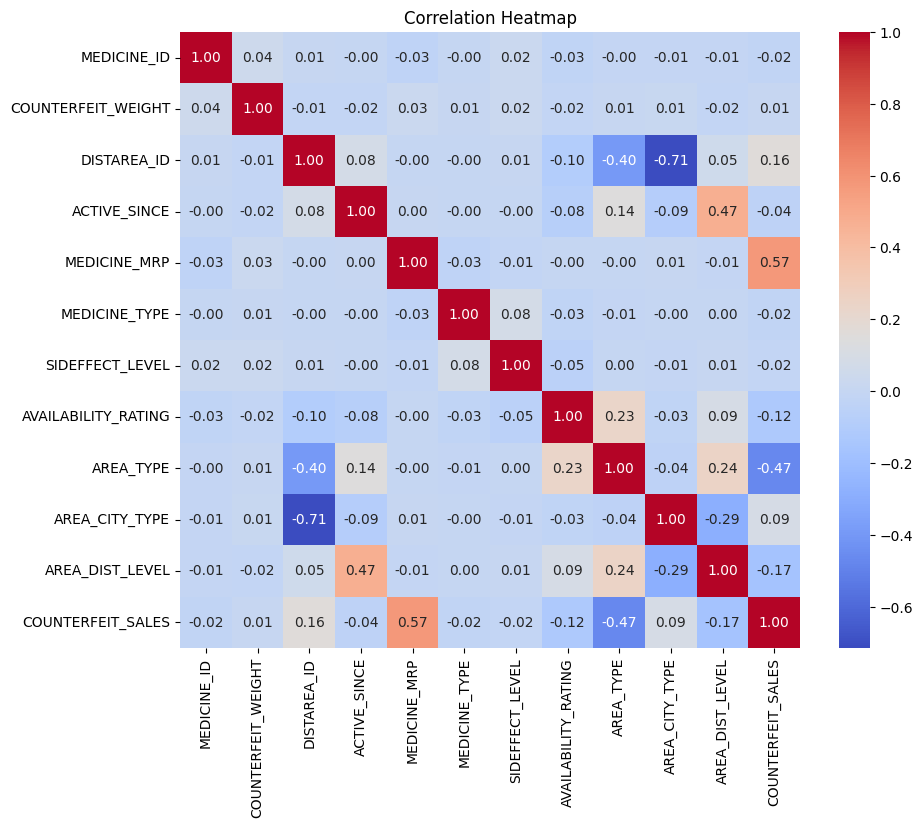

In [35]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation = train_data.corr()
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**The correlation heatmap identifies relationships between numerical variables, helping you detect multicollinearity or highly correlated features.**